In [1]:
import scipy
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

from sklearn import linear_model    # Herramientas de modelos lineales
from sklearn.metrics import mean_squared_error, r2_score    # Medidas de desempeño
from sklearn.preprocessing import PolynomialFeatures    # Herramientas de polinomios
from sklearn.model_selection import train_test_split

from formulaic import Formula

## Pregunta 2

Ingresar un código para generar el gráfico a partir de los datos de Gapminder, utilizando Seaborn Objects.

In [2]:
gapminder = pd.read_csv("../../datasets/gapminder.csv")

In [3]:
gapminder

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106
...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623


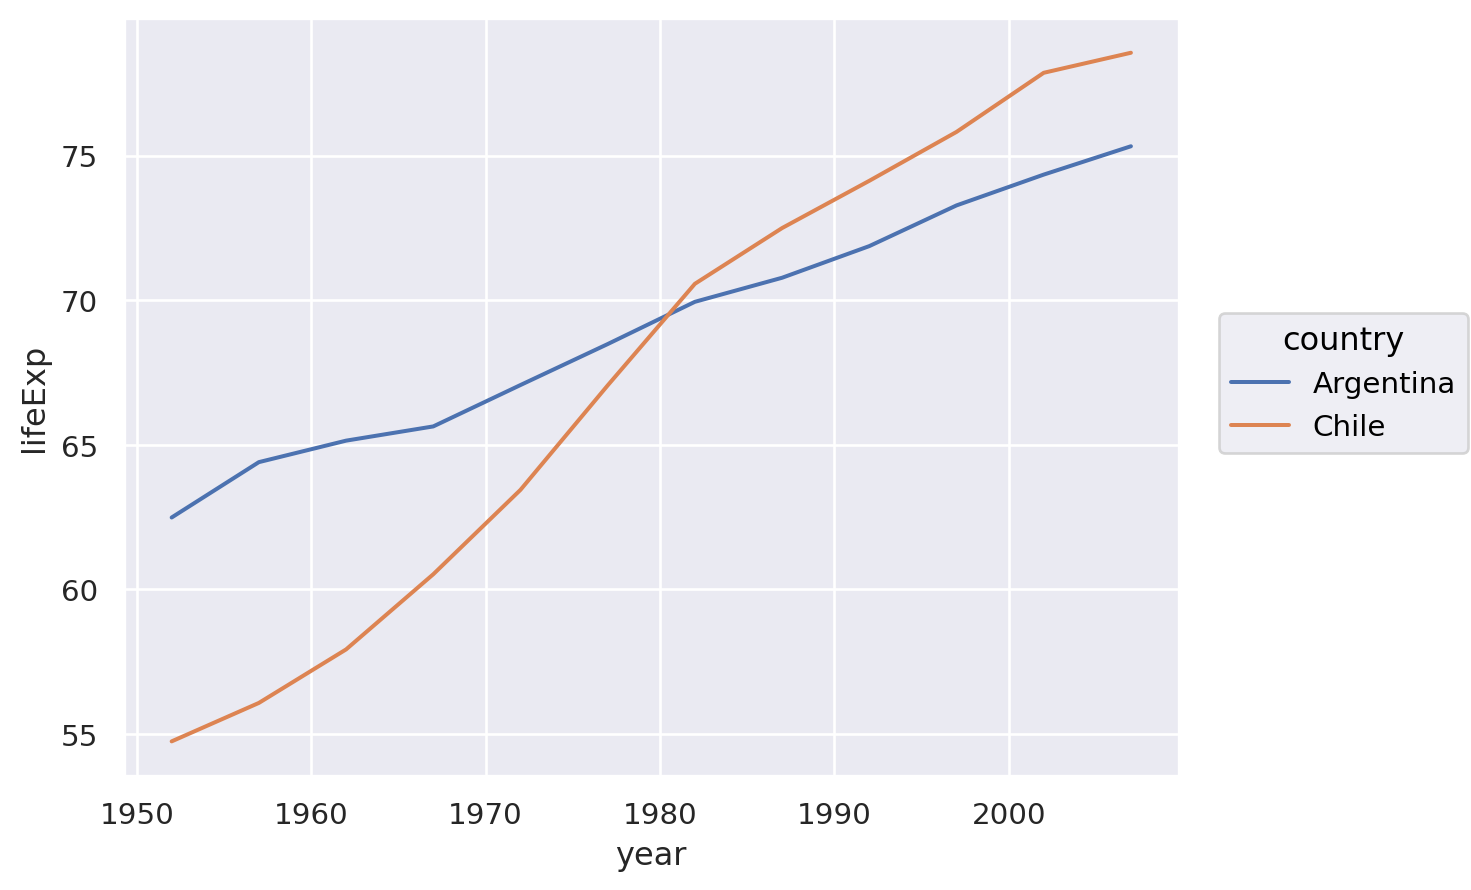

In [4]:
arg_chi = gapminder[gapminder["country"].isin(["Argentina","Chile"])]

(
    so.Plot(arg_chi, 'year','lifeExp',color='country')
    .add(so.Line())
)

## Pregunta 3
Descargar el archivo data_Kmeans.csv e implementar un código para seleccionar visualmente el valor óptimo de k mediante  el método del codo, considerando valores de k entre 1 y 10 ambos inclusive.

¿Qué valor de k considera apropiado?

Sugerencias:

El valor de WCSS (within-cluster sum of squares) corresponde al atributo inertia_ de KMeans.
Puede guardar los valores de WCSS en una lista con el siguiente código (no es necesario seguir exactamente este código).


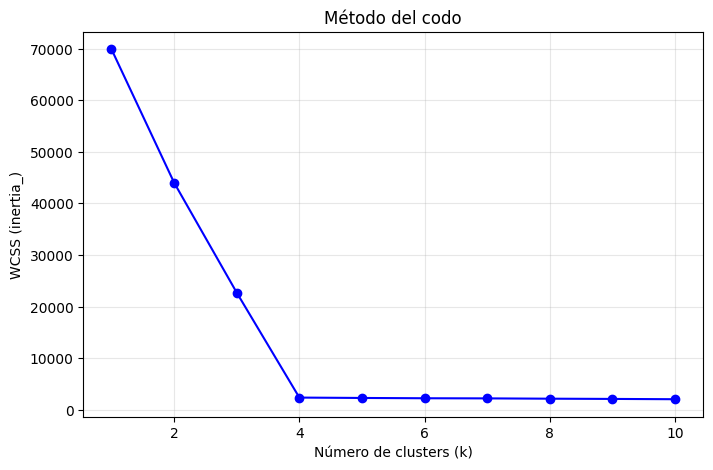

In [21]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df= pd.read_csv('data_Kmeans.csv')
X = df.values

k_values = list(range(1,11))
WCSS = []
for k in k_values:
    # Realizamos el agrupamiento en k clusters
    kmeans= KMeans(n_clusters=k, init='k-means++',n_init="auto",random_state=0)
    kmeans.fit(X)

    # Guardamos el valor de WCSS
    WCSS.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, WCSS, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('WCSS (inertia_)')
plt.title('Método del codo')
#plt.xticks(k_values)
plt.grid(True, alpha=0.3)
#plt.savefig('elbow_plot.png', dpi=150, bbox_inches='tight')
#print("Gráfico guardado")


## Ejercicio 5
El código que se da a continuación genera un conjunto de 200 datos en la matriz X y una variable binaria y que indica a qué clase pertenece cada dato.

Escribir un código que prediga la clase de los siguientes puntos utilizando KNN con k = 5:
<ul>
<li>(0,1)</li>
<li>(-2,1)</li>
<li>(2,-1)</li>
</ul>

In [32]:
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier

X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    class_sep=0.9,
    hypercube=True,
    random_state=42
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X,y)
X_pred = np.array([
    [0,1],
    [-2,1],
    [2,-1]
])

predicciones = knn.predict(X_pred)
print(predicciones)



[1 0 1]


## Pregunta 7
A partir del siguiente código se genera un conjunto de puntos en el plano que se guardan en la variable X_aniso

Dar un código que utilice DBSCAN para generar una variable de etiquetas que clasifique a los puntos de X_aniso en dos clusters (con algunos outliers) y realice un gráfico similar al que se muestra en la figura

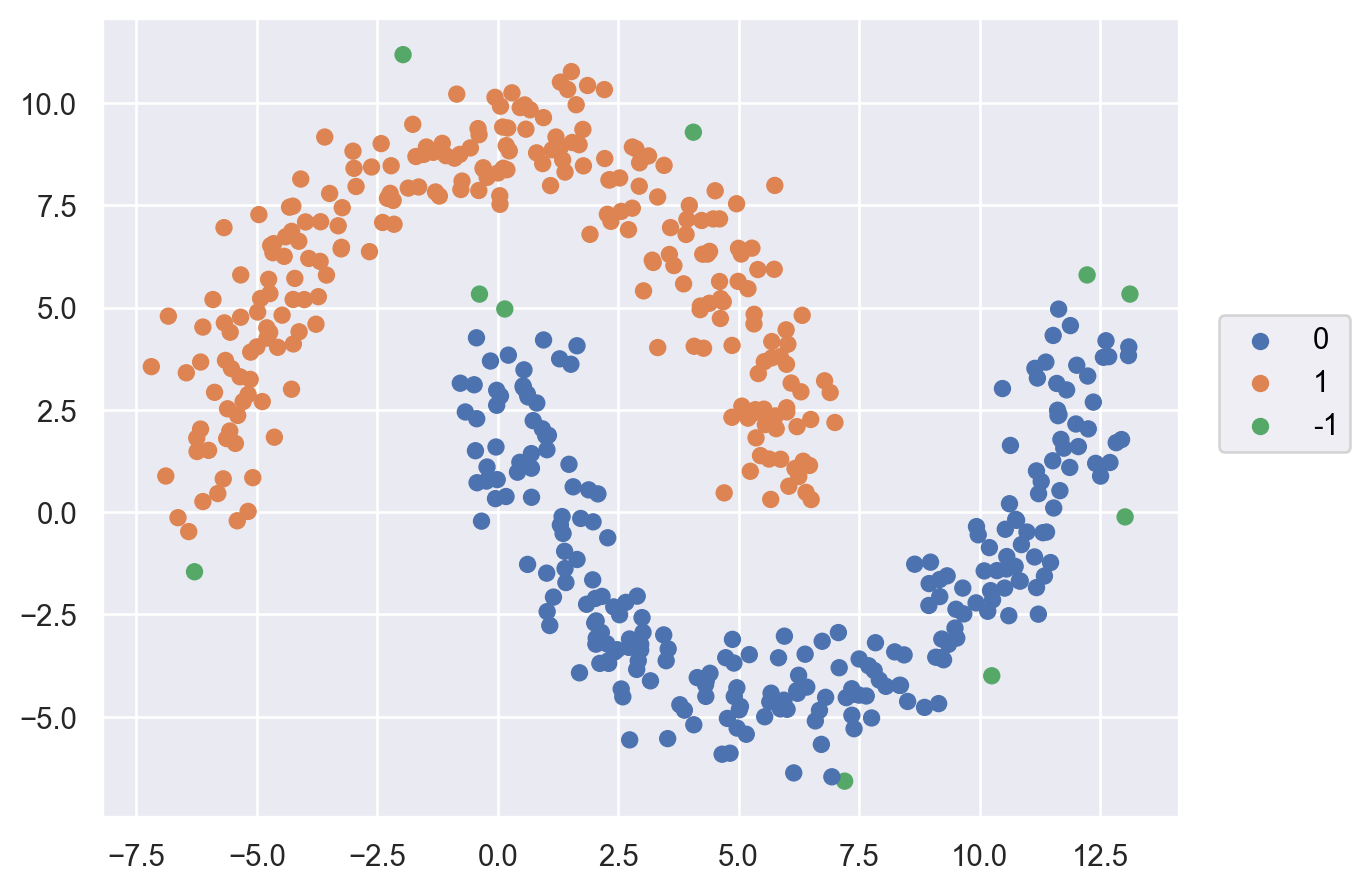

Clusters encontrados: 2, outliers: 10


Text(0.5, 1.0, 'DBSCAN sobre X_aniso')

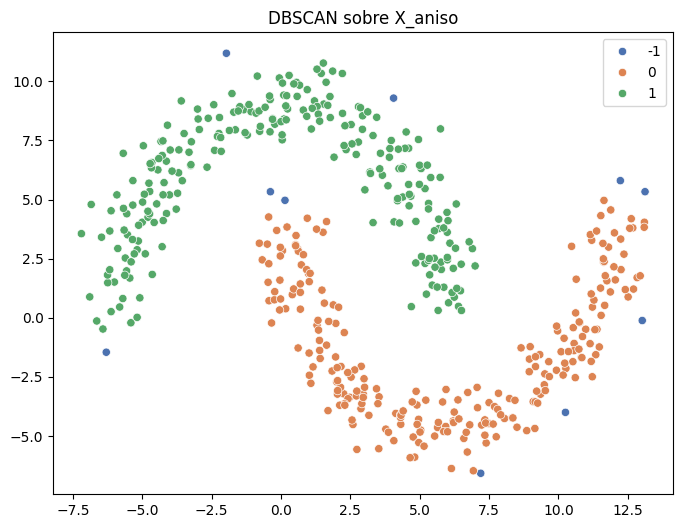

In [50]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

X, y = make_moons(n_samples=500, noise=0.1, random_state = 42)
transformation = [[6.0, 0], [0.2, 9.0]]

X_aniso = np.dot(X, transformation)

db= DBSCAN(eps=0.92,min_samples=5)

labels= db.fit_predict(X_aniso)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_outliers = list(labels).count(-1)
print(f"Clusters encontrados: {n_clusters}, outliers: {n_outliers}")
 
# Graficamos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_aniso[:, 0], y=X_aniso[:, 1], hue=labels, palette='deep', legend='full')
plt.title('DBSCAN sobre X_aniso')

 

## Pregunta 13
Completar el siguiente código para realizar una regresión lineal donde se intente explicar lifeExp según gdpPercap para el dataset Gapminder, separando los datos en train y test para finalmente reportar el error cuadrático medio (MSE) en el conjunto de testeo

In [51]:
gapminder = pd.read_csv('gapminder.csv')
gapminder.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


In [53]:
gapminder = pd.read_csv('gapminder.csv')

y, X = Formula('lifeExp ~ gdpPercap').get_model_matrix(gapminder)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo
modelo = linear_model.LinearRegression(fit_intercept=True)

# Entrenamiento
modelo.fit(X_train, y_train)

# Evaluación
y_pred = modelo.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"MSE en test: {mse:.2f}")

MSE en test: 86.25


In [ ]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [ ]:
penguinsParcial = sns.load_dataset("penguins")

Escribir código que permita identificar cuántos datos faltantes hay en cada columna

In [ ]:
penguinsParcial.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

## Pregunta 16

Escribir una línea de código que permita obtener un dataframe a partir de penguins con todas las siguientes modificaciones(en orden):
<ol>
<li>Eliminar la columna con más datos faltantes</li>
<li>Eliminar las filas con algún dato faltante</li>
<li>renombrar la columna species a species_name</li>
<li>resetear los índices (descartar los índices anteriores)</li>
</ol>

In [ ]:
penguinsClean1 = penguinsParcial.drop(columns="sex")
penguinsClean1.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0
3,Adelie,Torgersen,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0


In [ ]:
penguinsClean2= penguinsClean1.dropna()
penguinsClean2

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0
...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0


In [ ]:
penguinsClean3 = penguinsClean2.rename(columns={"species":"species_name"})
penguinsClean3

,species_name,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0
...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0


In [ ]:
penguinsClean4 =  penguinsClean3.reset_index()
penguinsClean4

penguinsClean5= penguinsClean4.drop(columns="index")

penguinsClean5

,species_name,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0
...,...,...,...,...,...,...
337,Gentoo,Biscoe,47.2,13.7,214.0,4925.0
338,Gentoo,Biscoe,46.8,14.3,215.0,4850.0
339,Gentoo,Biscoe,50.4,15.7,222.0,5750.0
340,Gentoo,Biscoe,45.2,14.8,212.0,5200.0


In [ ]:
#Respuesta final
penguinsParcialRes = penguinsParcial.drop(columns="sex").dropna().rename(columns={"species":"species_name"}).reset_index(drop=True)

penguinsParcialRes

,species_name,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0
...,...,...,...,...,...,...
337,Gentoo,Biscoe,47.2,13.7,214.0,4925.0
338,Gentoo,Biscoe,46.8,14.3,215.0,4850.0
339,Gentoo,Biscoe,50.4,15.7,222.0,5750.0
340,Gentoo,Biscoe,45.2,14.8,212.0,5200.0


## Pregunta 17

Usando el conjunto de datos Gapminder, escribir un código que calcule qué porcentaje de la población mundial correspondía a cada continente en el año 2007.

(Es un gráfico de líneas que muestra lifeExp por país de Argentina y Chile)

In [ ]:
# nos quedamos sólo con los datos de 2007

pop2007 = gapminder[gapminder["year"] == 2007]

poblacion_total = pop2007["pop"].sum()
poblacion_continentes = pop2007.groupby("continent")["pop"].sum()
poblacion_continentes

porcentajes_poblacion_por_continente = poblacion_continentes/poblacion_total

porcentajes_poblacion_por_continente * 100

continent
Africa      14.870224
Americas    14.379608
Asia        60.981376
Europe       9.376057
Oceania      0.392735
Name: pop, dtype: float64

## Pregunta 19

A partir del dataset diamonds de seaborn:

Escribir código que permita :
<ol>
<li>Replicar el gráfico que se ve en el enunciado (con la misma cantidad de barras)</li>
<li>Calcular (mediante operaciones con los datos, no mediante la información del gráfico) el ancho de cada barra.</li>
</ol>

En la respuesta, escribir el código para ambos ítems e indicar el resultado obtenido para el ítem 2.

In [ ]:
diamonds= sns.load_dataset('diamonds')
diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


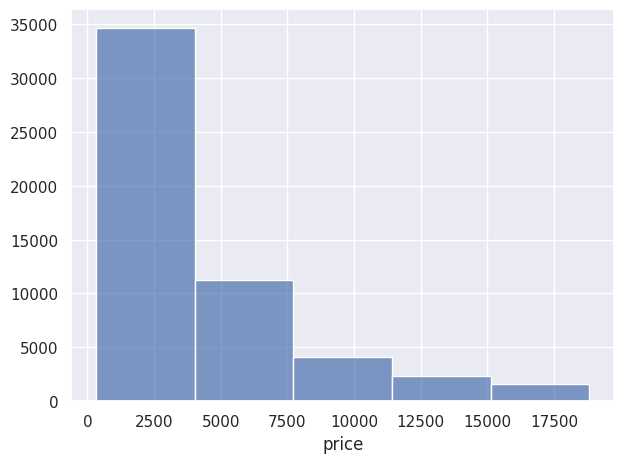

El ancho de cada barra será: $ 3699.4


In [ ]:
(
    so.Plot(diamonds, x="price")
    .add(so.Bars(), so.Hist(bins=5))
    .show()
)
precio_max = diamonds["price"].max()
precio_min = diamonds["price"].min()

print("El ancho de cada barra será: $",(precio_max - precio_min)/5)